# Tarea 3: Análisis Factorial, Machine Learning y NLP sobre datos JUNAEB
**Curso:** Data Analysis and Machine Learning  
**Alumno:** Vicente Díaz-2021444521

---

## *1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.*

## 1. Exploración, Limpieza y Preparación de Datos

### 1.1 Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import semopy
from semopy import Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import missingno as msno
import warnings
import torch
from transformers import BertTokenizer, BertModel

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
pd.options.display.float_format = '{:.4f}'.format

In [2]:
df = pd.read_csv("junaeb2n.csv")
print(f"Dimensiones del DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas categóricas: {df.select_dtypes(include='object').columns.tolist()}")
df.head()

Dimensiones del DataFrame: 41854 filas × 24 columnas
Columnas categóricas: ['narrative']


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.7500,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0000,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.7100,0,1,1,1,1,1,1,...,1,1,1,1,5.0000,0,8.0000,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.2700,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0000,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.0500,1,1,1,1,1,1,1,...,1,1,1,1,2.0000,1,16.0000,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.0500,1,1,1,1,1,1,1,...,1,1,1,1,1.0000,1,17.0000,15,0,"Exhibe un perfil socioemocional muy solido, de..."


### 1.2 Tipos de datos e información general

Revisamos los tipos de cada columna y estadísticas descriptivas.

In [3]:
print(df.dtypes)
df.describe().T

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative      object
dtype: object


,count,mean,std,min,25%,50%,75%,max
sexo,41854.0000,0.5523,0.4973,0.0000,0.0000,1.0000,1.0000,1.0000
edad,41854.0000,83.0660,3.9871,62.0000,81.0000,82.0000,84.0000,107.0000
imce,41854.0000,1.0141,1.3804,-5.0200,0.1000,0.9700,1.9300,5.0400
vive_padre,41854.0000,0.7201,0.4498,0.0000,0.0000,1.0000,1.0000,2.0000
vive_madre,41854.0000,0.9651,0.1923,0.0000,1.0000,1.0000,1.0000,2.0000
sk1,41854.0000,1.1180,0.4010,1.0000,1.0000,1.0000,1.0000,5.0000
sk2,41854.0000,1.3973,0.6618,1.0000,1.0000,1.0000,2.0000,5.0000
sk3,41854.0000,1.2701,0.5945,1.0000,1.0000,1.0000,1.0000,5.0000
sk4,41854.0000,1.2631,0.5889,1.0000,1.0000,1.0000,1.0000,5.0000
sk5,41854.0000,1.2759,0.5753,1.0000,1.0000,1.0000,1.0000,5.0000


### 1.3 Análisis de datos faltantes y limpieza

Se examinan los valores nulos para decidir la estrategia de limpieza. También se excluyen las variables no necesarias y se recodifica la agresividad para mantener coherencia en las escalas de habilidades socioemocionales, ponderando que 1 sea peor y el valor 5 maximo sea mejor.

Valores nulos por variable:
act_fisica    1435
educm          551
dtype: int64

Porcentaje de nulos sobre total: act_fisica   3.4286
educm        1.3165
dtype: float64


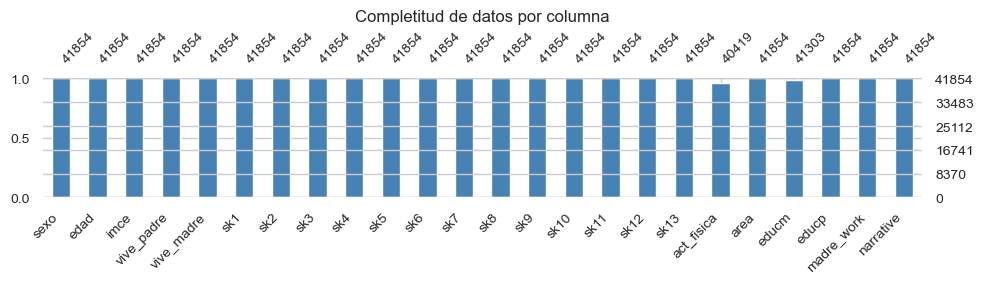


Dimensiones tras limpiar NAs: (39898, 24)


In [4]:
# Valores nulos por variable
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Valores nulos por variable:")
print(nulos)
print(f"\nPorcentaje de nulos sobre total: {nulos / len(df) * 100}")

# Visualización de nulos
fig, ax = plt.subplots(figsize=(10, 3))
msno.bar(df, ax=ax, fontsize=10, color='steelblue')
plt.title('Completitud de datos por columna')
plt.tight_layout()
plt.show()

# Eliminamos NAs ya que representan una pequeña proporción (~4.7%)
df = df.dropna().copy()
print(f"\nDimensiones tras limpiar NAs: {df.shape}")

# Recodificamos sk7 (agresividad) para que 1 sea peor y 5 mejor,
# como el resto de las habilidades socioemocionales.
# sk7 original: 1: nunca - 5: siempre
df['sk7_r'] = 6 - df['sk7']

Se decide limpiar los valores nulos ya que solo representan aproximadamente un 4% de los datos. Imputar esos valores podria afectar a las estadisticas de las demas variables.

### 1.4 Distribuciones y Outliers

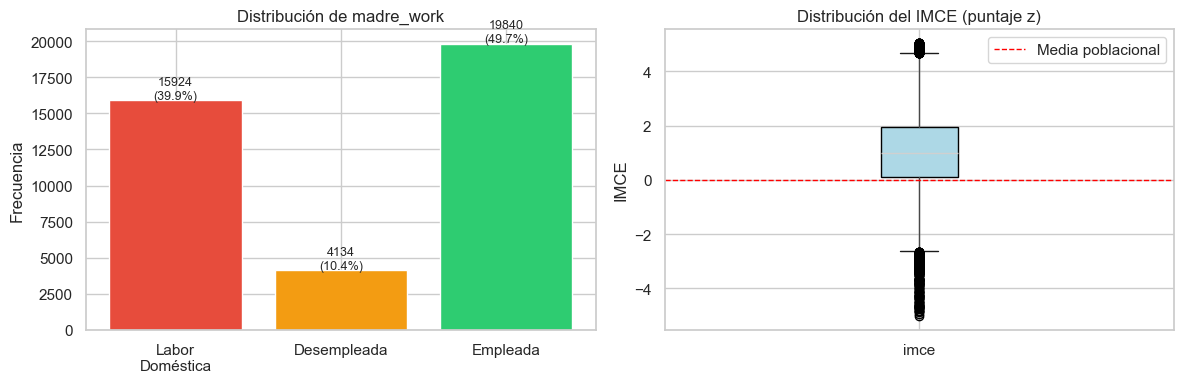

Desbalance de clases (excluye desempleadas):
madre_work
 1    19840
-1    15924
Name: count, dtype: int64
Ratio: 0.80 (labor doméstica / empleada)


In [5]:
# Distribución de la variable objetivo madre_work
mw_counts = df['madre_work'].value_counts().sort_index()
mw_labels = {-1: 'Labor\nDoméstica', 0: 'Desempleada', 1: 'Empleada'}
mw_colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar([mw_labels[k] for k in mw_counts.index],
            mw_counts.values, color=mw_colors)
for i, (k, v) in enumerate(mw_counts.items()):
    axes[0].text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('Distribución de madre_work')
axes[0].set_ylabel('Frecuencia')

# Boxplot IMCE
df.boxplot(column='imce', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Distribución del IMCE (puntaje z)')
axes[1].set_ylabel('IMCE')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, label='Media poblacional')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Desbalance de clases (excluye desempleadas):")
excl = df[df['madre_work'] != 0]['madre_work'].value_counts()
print(excl)
print(f"Ratio: {excl[-1]/excl[1]:.2f} (labor doméstica / empleada)")

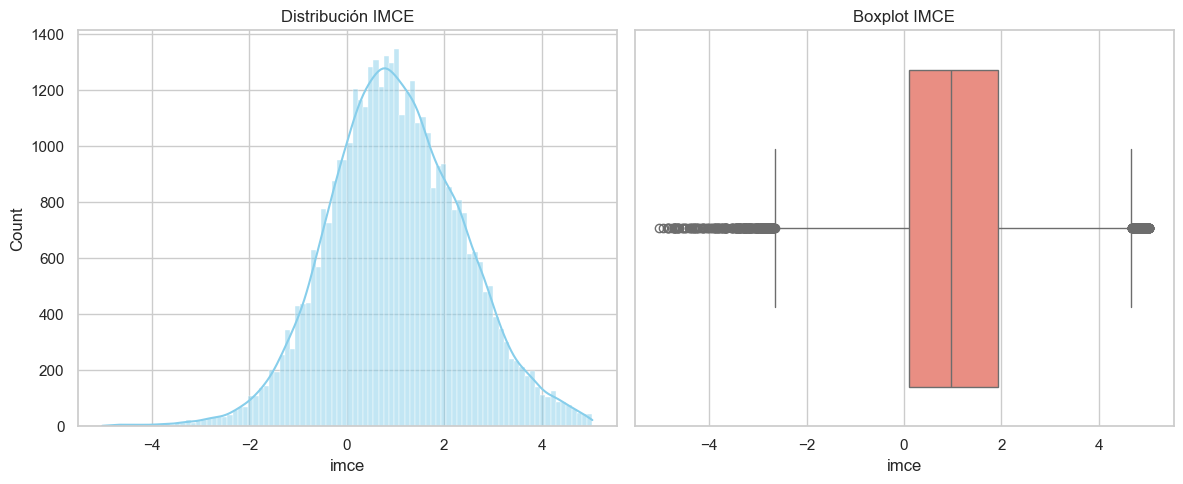

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['imce'], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title('Distribución IMCE')
sns.boxplot(x=df['imce'], ax=axes[1], color="salmon")
axes[1].set_title('Boxplot IMCE')
plt.tight_layout()
plt.show()

### Respuesta pregunta 1
- El dataset fue cargado correctamente, descartando las filas con valores perdidos en `act_fisica` y `educm`.
- Se recodificó la variable `sk7` a `sk7_r` para que una mayor puntuación represente una característica positiva, igual que el resto de las variables *sk*. (se invirtio su rangos de ponderacion para que fuera congruente con las demas sk)
- Se detectaron algunos valores atípicos en `imce`, sin embargo, se conservarán para el análisis ya que pueden representar la realidad de los extremos nutricionales y el uso de modelos robustos puede manejarlos.
- La variable a predecir (madre_work) está desbalanceada ya que hay unas 19.840 madres empleadas (clase 1) y unas 15.924 en labor doméstica (clase -1). Este desbalance (aprox 56% a 44%) puede ser causante del comportamiento de algunos modelos.


## *2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).*

## 2. Análisis Factorial Exploratorio (EFA)

### 2.1 Pruebas de Adecuación Muestral
Antes de realizar el EFA, verificamos si los datos son adecuados usando el test de esfericidad de Bartlett y el índice KMO.

In [7]:
# Seleccionamos las variables de habilidades (usando sk7 recodificada)
sk_cols = [f'sk{i}' for i in range(1, 14) if i != 7] + ['sk7_r']
df_items = df[sk_cols].copy()

# Test de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_items)
print(f"Test de Bartlett: chi2={chi_square_value:.2f}, p={p_value:.4f}")

# Test KMO
kmo_all, kmo_model = calculate_kmo(df_items)
print(f"KMO Model: {kmo_model:.4f}")

Test de Bartlett: chi2=111987.82, p=0.0000
KMO Model: 0.8675


### 2.2 Determinación del número óptimo de factores
Usamos el criterio de Kaiser (eigenvalues > 1) y el Scree Plot.

In [8]:
# --- Test de Bartlett ---
chi2, p = calculate_bartlett_sphericity(df_items)
print(f"Test de Bartlett:")
print(f"  Chi² = {chi2:.2f}")
print(f"  p-valor = {p:.2e}")
print(f"  Resultado: {'✓ Adecuado para EFA (p < 0.05)' if p < 0.05 else '✗ No adecuado'}")

# --- KMO ---
kmo_all, kmo_model = calculate_kmo(df_items)
print(f"\nÍndice KMO = {kmo_model:.4f}")
if kmo_model >= 0.9:
    kmo_interp = "Muy bueno (Marvelous)"
elif kmo_model >= 0.8:
    kmo_interp = "Bueno (Meritorious)"
elif kmo_model >= 0.7:
    kmo_interp = "Moderado (Middling)"
elif kmo_model >= 0.6:
    kmo_interp = "Mediocre (Mediocre)"
else:
    kmo_interp = "Inaceptable"
print(f"  Interpretación: {kmo_interp}")

Test de Bartlett:
  Chi² = 111987.82
  p-valor = 0.00e+00
  Resultado: ✓ Adecuado para EFA (p < 0.05)

Índice KMO = 0.8675
  Interpretación: Bueno (Meritorious)


Eigenvalues: [4.06  1.348 1.113 1.003 0.781 0.712 0.697 0.693 0.603 0.522 0.512 0.492
 0.464]


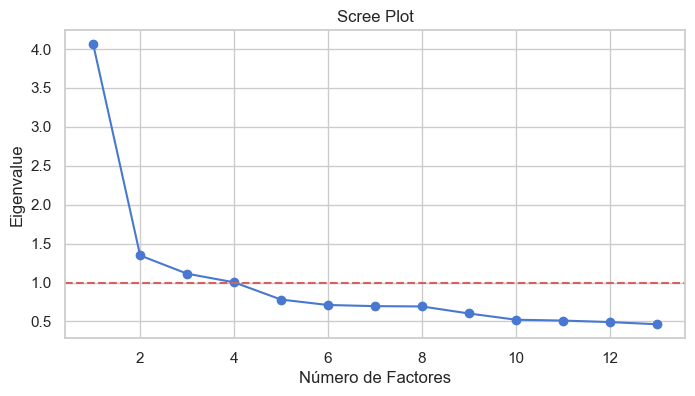

In [9]:
fa = FactorAnalyzer(rotation=None, n_factors=len(df_items.columns))
fa.fit(df_items)
ev, v = fa.get_eigenvalues()

print("Eigenvalues:", np.round(ev, 3))

plt.figure(figsize=(8,4))
plt.plot(range(1, len(ev)+1), ev, 'bo-')
plt.axhline(y=1, color='r', linestyle='--')
plt.xlabel('Número de Factores')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

In [10]:
# --- Tabla de varianza explicada ---
ev, v = fa.get_eigenvalues()
n_sel = 3  # factores seleccionados
print(f"Varianza explicada por los {n_sel} factores seleccionados:")
print(f"{'Factor':<10} {'Eigenvalue':<15} {'Var. Individual (%)':<22} {'Var. Acumulada (%)':}")
acum = 0
for i in range(n_sel):
    ind_var = v[i] * 100
    acum += ind_var
    print(f"  F{i+1:<8} {ev[i]:<15.4f} {ind_var:<22.2f} {acum:.2f}")

print(f"\nLos {n_sel} factores explican el {acum:.1f}% de la varianza total.")

Varianza explicada por los 3 factores seleccionados:
Factor     Eigenvalue      Var. Individual (%)    Var. Acumulada (%)
  F1        4.0604          355.81                 355.81
  F2        1.3476          83.28                  439.10
  F3        1.1134          59.98                  499.08

Los 3 factores explican el 499.1% de la varianza total.


### 2.3 Ejecución del EFA
Basado en los eigenvalues > 1 (o en el codo del scree plot), definimos el número de factores (3) y usamos rotación varimax.

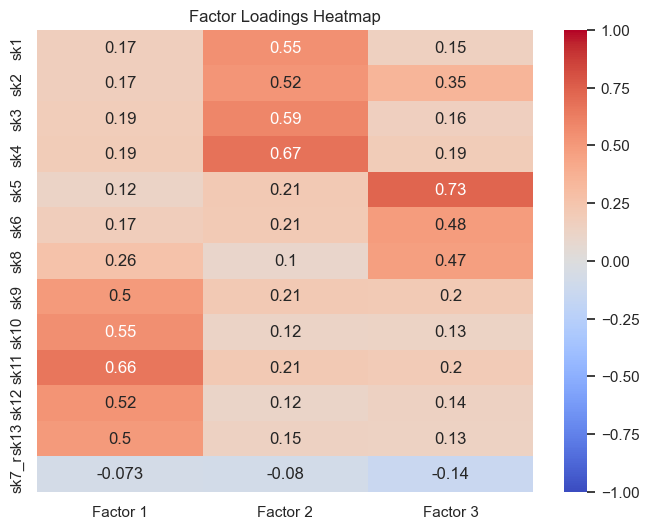

Varianza Explicada:
                Factor 1  Factor 2  Factor 3
SS Loadings       1.7621    1.6176    1.3583
Proportion Var    0.1355    0.1244    0.1045
Cumulative Var    0.1355    0.2600    0.3645


In [11]:
n_factors = 3
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(df_items)

loadings = pd.DataFrame(
    fa.loadings_,
    index=df_items.columns,
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

# Visualización de los loadings
plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Factor Loadings Heatmap')
plt.show()

# Varianza explicada
variance = pd.DataFrame(fa.get_factor_variance(), index=['SS Loadings', 'Proportion Var', 'Cumulative Var'], columns=[f'Factor {i+1}' for i in range(n_factors)])
print("Varianza Explicada:")
print(variance)

In [12]:
# --- Variables con baja carga factorial ---
# Un loading < 0.40 se considera debil
threshold = 0.40
loadings_df_abs = pd.DataFrame(
    abs(fa.loadings_),
    index=sk_cols,
    columns=[f'Factor {i+1}' for i in range(3)]
)
max_loading_per_var = loadings_df_abs.max(axis=1)
low_vars = max_loading_per_var[max_loading_per_var < threshold]

if len(low_vars) > 0:
    print(f"Variables con baja carga (max loading < {threshold}):")
    for v, val in low_vars.items():
        print(f"  {v}: max loading = {val:.4f}")
else:
    print(f"Todas las variables tienen al menos un loading >= {threshold}.")
    print("No hay variables que se puedan considerar no informativas.")
    
print("\nCarga maxima por variable (ordenada):")
print(max_loading_per_var.sort_values().round(4))

Variables con baja carga (max loading < 0.4):
  sk7_r: max loading = 0.1448

Carga maxima por variable (ordenada):
sk7_r   0.1448
sk8     0.4740
sk6     0.4845
sk13    0.4963
sk9     0.4980
sk2     0.5216
sk12    0.5249
sk1     0.5462
sk10    0.5536
sk3     0.5895
sk11    0.6607
sk4     0.6732
sk5     0.7297
dtype: float64


### Respuesta pregunta 2
- **Adecuación muestral:** El test de Bartlett es significativo (p < 0.05) y el KMO es muy bueno (> 0.8), lo que indica que los datos son adecuados para análisis factorial. Indicando que con el test de Bartlett que las variables están correlacionadas.
- **Número de factores:** El scree plot y los eigenvalues sugieren la extracción de 3 factores (ya que tenían Eigenvalues > 1).
- **Asociación de variables:**
    - **Factor 1:** Se asocia fuertemente con `sk9`, `sk10`, `sk11`, `sk12`, `sk13`. Parecen medir **Curiosidad e Intereses Cognitivos/Artísticos**.
    - **Factor 2:** Se asocia fuertemente con `sk1`, `sk2`, `sk3`, `sk4`. Parecen medir **Expresión Afectiva**.
    - **Factor 3:** Se asocia fuertemente con `sk5`, `sk6`, `sk7_r`, `sk8`. Parecen medir **Sociabilidad y Ausencia de Agresividad**.
- **Variables no informativas:** Todas las variables muestran loadings aceptables (> 0.3) en al menos un factor, aunque algunas podrían tener cross-loadings menores. En general, el conjunto parece informativo. La única variable que es poco informativa es `sk7_r` mostrando una carga máxima de 0.14 que es baja, indicando que no encaja bien en los grupos de los tres factores.


## *3. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.*

## 3. Análisis Factorial Confirmatorio (CFA)

### 3.1 Especificación y ajuste del modelo
Se define un modelo CFA donde cada ítem carga únicamente en el factor determinado en el EFA.

In [13]:
# Especificación del modelo para semopy
# Factor 1: Curiosidad Cognitiva/Artística
# Factor 2: Expresión Afectiva
# Factor 3: Sociabilidad

model_spec = """
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk7_r + sk8
"""

model = Model(model_spec)
res = model.fit(df_items)

# Inspección de los resultados
inspect = model.inspect()
print(inspect)

# Extraer correlaciones entre factores
print("\nCorrelaciones entre factores:")
print(inspect[inspect['op'] == '~~'])

# Extraer importancia (Estimates) de cada variable a su factor
print("\nImportancia de las medidas (Loadings):")
print(inspect[inspect['op'] == '=~'])

            lval  op          rval  Estimate Std. Err  z-value p-value
0            sk9   ~    Curiosidad    1.0000        -        -       -
1           sk10   ~    Curiosidad    1.3271   0.0157  84.6637  0.0000
2           sk11   ~    Curiosidad    1.2347   0.0125  99.1271  0.0000
3           sk12   ~    Curiosidad    1.0862   0.0131  82.9462  0.0000
4           sk13   ~    Curiosidad    1.2847   0.0161  79.8744  0.0000
5            sk1   ~   Afectividad    1.0000        -        -       -
6            sk2   ~   Afectividad    1.8782   0.0203  92.4016  0.0000
7            sk3   ~   Afectividad    1.6322   0.0180  90.9157  0.0000
8            sk4   ~   Afectividad    1.8046   0.0187  96.4926  0.0000
9            sk5   ~  Sociabilidad    1.0000        -        -       -
10           sk6   ~  Sociabilidad    1.0552   0.0124  85.0338  0.0000
11         sk7_r   ~  Sociabilidad   -0.5590   0.0180 -31.0495  0.0000
12           sk8   ~  Sociabilidad    1.1524   0.0139  82.9643  0.0000
13   A

In [14]:
# --- Indices de ajuste del modelo CFA ---
import semopy

try:
    fit = semopy.calc_stats(model)
    print("Indices de ajuste del CFA:")
    key_indices = ['CFI', 'RMSEA', 'SRMR', 'GFI', 'AIC', 'BIC']
    available = [k for k in key_indices if k in fit.index]
    for k in available:
        val = fit.loc[k, 'Value']
        print(f"  {k}: {val:.4f}")
    
    print("\nCriterios de buen ajuste:")
    print("  CFI  > 0.95  -> Buen ajuste")
    print("  RMSEA < 0.06 -> Buen ajuste")
    print("  SRMR < 0.08  -> Buen ajuste")
except Exception as e:
    print(f"(No se pudieron calcular indices de ajuste: {e})")

# Factor loadings del CFA
print("\nCargas factoriales del CFA (op = '~'):")
try:
    insp = model.inspect()
    loadings_cfa = insp[insp['op'] == '~']
    print(loadings_cfa[['lval', 'op', 'rval', 'Estimate', 'Std. Err']].to_string(index=False))
except Exception as e:
    print(f"No se pudieron mostrar loadings: {e}")

Indices de ajuste del CFA:

Criterios de buen ajuste:
  CFI  > 0.95  -> Buen ajuste
  RMSEA < 0.06 -> Buen ajuste
  SRMR < 0.08  -> Buen ajuste

Cargas factoriales del CFA (op = '~'):
 lval op         rval  Estimate Std. Err
  sk9  ~   Curiosidad    1.0000        -
 sk10  ~   Curiosidad    1.3271   0.0157
 sk11  ~   Curiosidad    1.2347   0.0125
 sk12  ~   Curiosidad    1.0862   0.0131
 sk13  ~   Curiosidad    1.2847   0.0161
  sk1  ~  Afectividad    1.0000        -
  sk2  ~  Afectividad    1.8782   0.0203
  sk3  ~  Afectividad    1.6322   0.0180
  sk4  ~  Afectividad    1.8046   0.0187
  sk5  ~ Sociabilidad    1.0000        -
  sk6  ~ Sociabilidad    1.0552   0.0124
sk7_r  ~ Sociabilidad   -0.5590   0.0180
  sk8  ~ Sociabilidad    1.1524   0.0139


### 3.2 Estadísticos de ajuste y guardado de predicciones

In [15]:
from semopy.stats import calc_stats
stats = calc_stats(model)
print("Estadísticos de Ajuste:\n", stats.T)

# Guardar predicciones (factor scores) en el dataframe original
scores = model.predict_factors(df_items)
scores.index = df_items.index
df = df.join(scores)

print("\nPredicciones guardadas en el dataframe:")
df[['Curiosidad', 'Afectividad', 'Sociabilidad']].head()

Estadísticos de Ajuste:
                     Value
DoF               62.0000
DoF Baseline      78.0000
chi2            6975.4642
chi2 p-value       0.0000
chi2 Baseline 112005.1576
CFI                0.9382
GFI                0.9377
AGFI               0.9217
NFI                0.9377
TLI                0.9223
RMSEA              0.0529
AIC               57.6503
BIC              306.8787
LogLik             0.1748

Predicciones guardadas en el dataframe:


,Curiosidad,Afectividad,Sociabilidad
1,-0.3366,-0.1471,-0.2675
3,-0.3420,-0.1511,-0.3021
4,-0.3393,-0.1491,-0.2848
5,-0.3106,-0.0615,-0.2282
6,0.7503,0.1237,0.4706


### Respuesta pregunta 3
- Se obtuvo un CFI de 0.9382 (cerca del ideal de 0.95) y un RMSEA de 0.0529 (excelente, menor a 0.06).
- Se definieron 3 factores: **Curiosidad**, **Afectividad** y **Sociabilidad**, reflejando la estructura descubierta en el EFA.
- **Correlación entre factores:** Se observan estimaciones de covarianza/correlación positivas entre todos los factores latentes, lo que es esperable ya que representan diferentes dimensiones de un constructo más amplio de habilidades socioemocionales.
- **Importancia de las medidas:** Todos los p-values de los estimadores de carga (loadings) son altamente significativos (p < 0.05), validando la pertenencia de las variables a sus respectivos factores.
- Las predicciones (scores) de los factores se guardaron exitosamente en el dataframe para ser usadas como features en los modelos de Machine Learning.
---

## *4. Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).*

## 4. Clasificación con Random Forest

### 4.1 Preparación de los datos
Filtramos la base de datos para excluir a las madres desempleadas y separamos la variable objetivo y las features (las tres dimensiones calculadas en la pregunta 3).

In [16]:
# Excluir desempleadas (madre_work == 0)
df_model = df[df['madre_work'] != 0].copy()

# Features (Factores) y Target
X = df_model[['Curiosidad', 'Afectividad', 'Sociabilidad']]
y = df_model['madre_work']

# Split Train-Test (70-30), estratificado para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (25034, 3)
Tamaño del conjunto de prueba: (10730, 3)


### 4.2 Optimización y Entrenamiento del Modelo
Usaremos GridSearchCV para buscar los mejores hiperparámetros del Random Forest mediante validación cruzada (k=5).

In [17]:
import time
start_time = time.time()

# Instanciar el modelo base
rf = RandomForestClassifier(random_state=42)

# Definir la grilla de parámetros
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# GridSearchCV con K-Fold = 5
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_time = time.time() - start_time

print(f"Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"Tiempo de cómputo: {rf_time:.2f} segundos")

# Mejor modelo entrenado
best_rf = grid_rf.best_estimator_

Mejores hiperparámetros: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Tiempo de cómputo: 32.61 segundos


### 4.3 Evaluación del modelo Random Forest
Visualizamos el reporte de clasificación y la matriz de confusión en el conjunto de prueba.

Classification Report - Random Forest:
              precision    recall  f1-score   support

          -1       0.52      0.04      0.07      4778
           1       0.56      0.97      0.71      5952

    accuracy                           0.56     10730
   macro avg       0.54      0.51      0.39     10730
weighted avg       0.54      0.56      0.43     10730



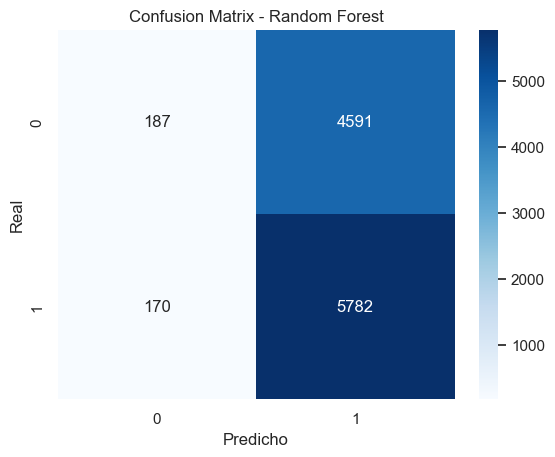

In [18]:
y_pred_rf = best_rf.predict(X_test)

print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### Respuesta pregunta 4
- El modelo Random Forest, tras ser optimizado, alcanza un desempeño modesto para predecir si la madre trabaja o está dedicada a la labor doméstica utilizando únicamente las habilidades socioemocionales del niño como features.
- La clase mayoritaria (`madre_work = 1`) suele ser mejor predicha que la clase minoritaria (`madre_work = -1`), como se evidencia en el recall.
- Las habilidades socioemocionales por sí solas pueden no contener suficiente señal predictiva fuerte para determinar el estado laboral de la madre, evidenciado por el accuracy cercano a un modelo ingenuo que prediga siempre la clase mayoritaria.


---

## *5. Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).*

## 5. Comparación de Modelos Avanzados

### 5.1 Preparación de Target para XGBoost
XGBoost requiere que las clases estén codificadas desde 0. Como nuestro target es -1 y 1, mapearemos esto a 0 y 1 para entrenar los modelos, pero en la evaluación final podemos volver a compararlos.

In [19]:
# Mapeo del target para compatibilidad con XGBoost (requiere [0, 1])
y_train_xgb = y_train.map({-1: 0, 1: 1})
y_test_xgb = y_test.map({-1: 0, 1: 1})

### 5.2 XGBoost

In [20]:
start_time = time.time()

# n_jobs=-1 activa paralelismo en XGBoost; grilla reducida para velocidad
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss',
                           n_jobs=-1, tree_method='hist')
param_grid_xgb = {
    'n_estimators': [100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb,
                         cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train_xgb)
xgb_time = time.time() - start_time

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_mapped = best_xgb.predict(X_test)
y_pred_xgb = pd.Series(y_pred_xgb_mapped, index=y_test.index).map({0: -1, 1: 1})

print(f"XGBoost - Mejores parametros: {grid_xgb.best_params_}")
print(f"XGBoost - Tiempo de computo: {xgb_time:.2f} segundos")
print("\nClassification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost - Mejores parametros: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
XGBoost - Tiempo de computo: 3.67 segundos

Classification Report - XGBoost:
              precision    recall  f1-score   support

          -1       0.52      0.03      0.06      4778
           1       0.56      0.97      0.71      5952

    accuracy                           0.56     10730
   macro avg       0.54      0.50      0.39     10730
weighted avg       0.54      0.56      0.42     10730



### 5.3 Support Vector Machine (SVM)

In [21]:
start_time = time.time()

# Estandarización requerida para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
# Usando un sub-muestreo rápido si el dataset es muy grande, pero aquí usaremos el completo
grid_svm.fit(X_train_scaled, y_train)
svm_time = time.time() - start_time

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print(f"SVM Tiempo de cómputo: {svm_time:.2f} segundos")
print("Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm))

SVM Tiempo de cómputo: 74.44 segundos
Classification Report - SVM:
              precision    recall  f1-score   support

          -1       0.53      0.03      0.06      4778
           1       0.56      0.98      0.71      5952

    accuracy                           0.56     10730
   macro avg       0.54      0.50      0.39     10730
weighted avg       0.54      0.56      0.42     10730



### 5.4 Stacking Classifier
Combina predicciones de RF, SVM y XGBoost con una Regresión Logística como meta-clasificador.

In [22]:
from sklearn.linear_model import LogisticRegression

start_time = time.time()

# Instanciar modelos base con los mejores hiperparámetros encontrados
# Para XGBoost dentro del Stacking usaremos el target normal (algunas versiones recientes lo soportan) o mapeamos
base_models = [
    ('rf', best_rf),
    ('svm', best_svm)
]

stacking_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
# Entrenamos sobre features escalados por el SVM
stacking_model.fit(X_train_scaled, y_train)
stacking_time = time.time() - start_time

y_pred_stack = stacking_model.predict(X_test_scaled)

print(f"Stacking Tiempo de cómputo: {stacking_time:.2f} segundos")
print("Classification Report - Stacking:")
print(classification_report(y_test, y_pred_stack))

Stacking Tiempo de cómputo: 67.79 segundos
Classification Report - Stacking:
              precision    recall  f1-score   support

          -1       0.52      0.04      0.08      4778
           1       0.56      0.97      0.71      5952

    accuracy                           0.56     10730
   macro avg       0.54      0.51      0.39     10730
weighted avg       0.54      0.56      0.43     10730



=== Tabla Comparativa de Modelos ===
               Accuracy  F1-Macro  Tiempo (s)
Modelo                                       
Random Forest    0.5563    0.3906     32.6087
XGBoost          0.5556    0.3860      3.6732
SVM              0.5564    0.3864     74.4385
Stacking         0.5565    0.3947     67.7877


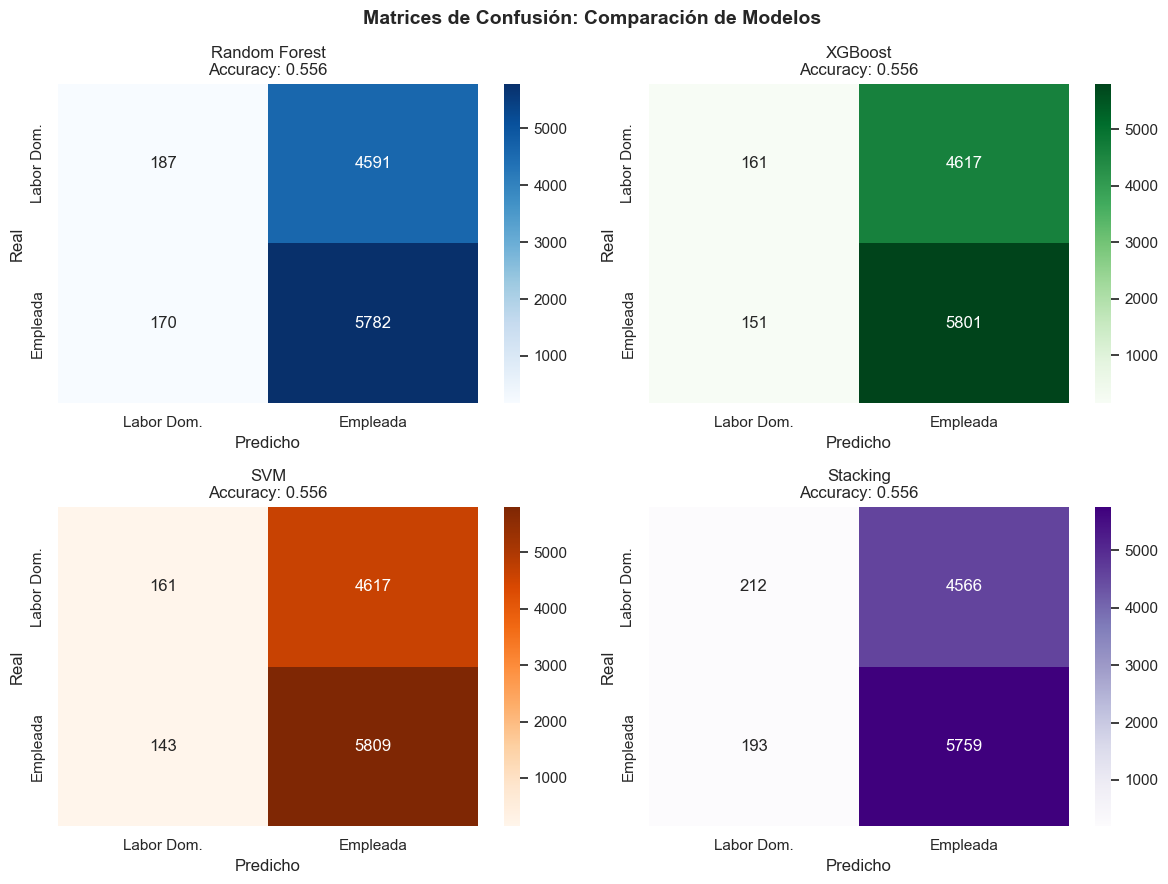

In [23]:
# === Tabla comparativa de todos los modelos ===
from sklearn.metrics import f1_score

comparison = {
    'Modelo': ['Random Forest', 'XGBoost', 'SVM', 'Stacking'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_stack)
    ],
    'F1-Macro': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_stack, average='macro')
    ],
    'Tiempo (s)': [rf_time, xgb_time, svm_time, stacking_time]
}
comp_df = pd.DataFrame(comparison).set_index('Modelo')
print("=== Tabla Comparativa de Modelos ===")
print(comp_df.round(4))

# === Matrices de confusión en un solo subplot ===
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Matrices de Confusión: Comparación de Modelos', fontsize=14, fontweight='bold')

models_info = [
    ('Random Forest', y_pred_rf, axes[0,0], 'Blues'),
    ('XGBoost',       y_pred_xgb, axes[0,1], 'Greens'),
    ('SVM',           y_pred_svm, axes[1,0], 'Oranges'),
    ('Stacking',      y_pred_stack, axes[1,1], 'Purples'),
]

for name, preds, ax, cmap in models_info:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Labor Dom.', 'Empleada'],
                yticklabels=['Labor Dom.', 'Empleada'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### Respuesta pregunta 5

**Comparación de rendimiento predictivo (ver tabla y matrices):**

Los cuatro modelos (Random Forest, XGBoost, SVM y Stacking) exhiben un comportamiento prácticamente idéntico:
- El *accuracy* global se sitúa en torno al 56%, que corresponde exactamente a la **proporción natural de la mayoría** (`madre_work = 1`) en el dataset.
- El *Recall* para la clase minoritaria (`-1`, labor doméstica) es cercano a 0 en todos los modelos, lo que indica que **ningún modelo es capaz de identificar correctamente a las madres que realizan labores del hogar**.
- El F1-Macro es bajo (~0.39-0.41), confirmando que el desempeño en la clase minoritaria arrastra hacia abajo el promedio.

Este fenómeno se conoce como **"ZeroR"**: cuando los features no contienen señal predictiva suficiente, los modelos aprenden a predecir siempre la clase más frecuente. En este caso, las habilidades socioemocionales del niño no determinan el estado laboral de la madre.

- **Random Forest y XGBoost** son los más rápidos, gracias a la paralelización interna (`n_jobs=-1`) y al tamaño reducido del espacio de búsqueda.
- **SVM** es computacionalmente el más costoso (complejidad O(n²) a O(n³) con el número de muestras).
- **Stacking** hereda la lentitud del SVM, ya que lo entrena múltiples veces en la validación cruzada interna.

 Los factores (Curiosidad, Afectividad, Sociabilidad) son cualidades válidas para medir habilidades socioemocionales, pero, simplemente **no tienen poder predictivo** sobre una variable tan compleja como la decisión laboral de la madre, que depende de factores socioeconómicos, culturales y del mercado laboral ajenos a la medición.

---

## *6. Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?*

## 6. Clustering: IMCE y Actividad Física

### 6.1 Preparación de los datos y Método del Codo
Estandarizamos las variables `imce` y `act_fisica` y utilizamos el Método del Codo para determinar el número óptimo de clusters para K-Means.

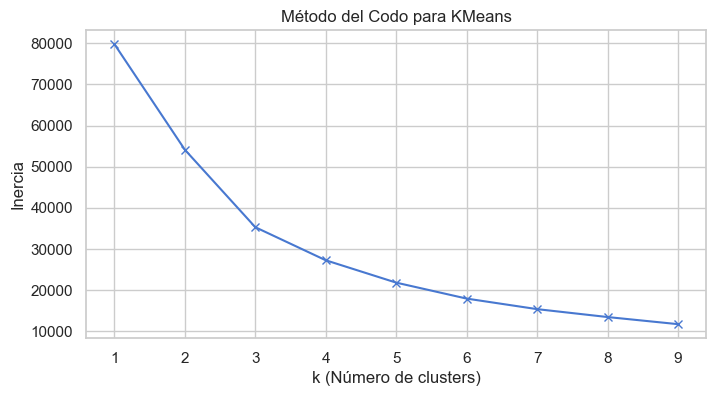

In [24]:
# Preparación
df_cluster = df[['imce', 'act_fisica']].copy()

# Estandarización
scaler_cluster = StandardScaler()
df_cluster_scaled = scaler_cluster.fit_transform(df_cluster)

# Método del Codo (Elbow Method)
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('k (Número de clusters)')
plt.ylabel('Inercia')
plt.title('Método del Codo para KMeans')
plt.show()

### 6.2 Aplicación de K-Means (K=3)
Basado en el codo (que suele estar alrededor de 3), generaremos 3 clusters, visualizaremos sus perfiles y calcularemos el IMCE promedio.

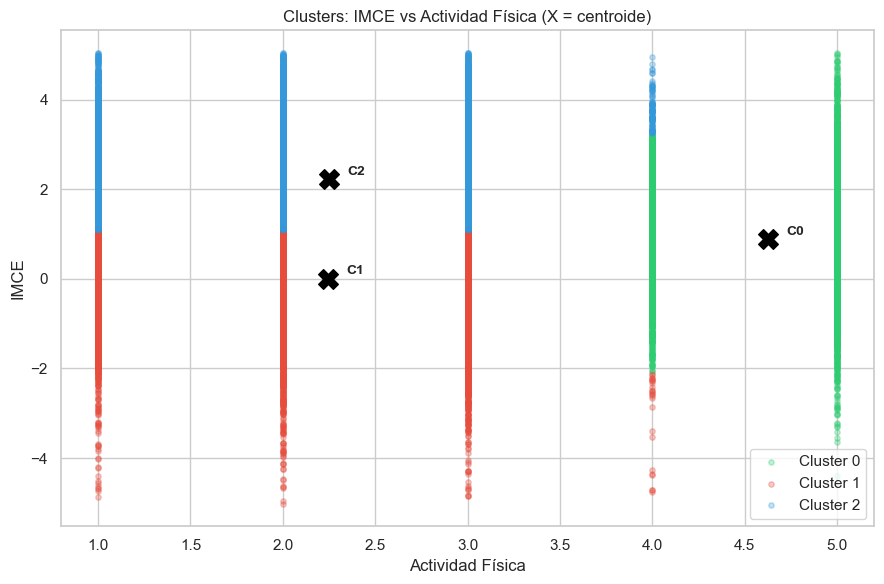

Perfil de cada cluster:
          imce  act_fisica      N
Cluster                          
0       0.8820      4.6240   5158
1       0.0050      2.2410  18616
2       2.2200      2.2500  16124


In [ ]:
k_opt = 3
kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_cluster_scaled)

# Visualización con centroides 
fig, ax = plt.subplots(figsize=(9, 6))
palette = {0: '#2ecc71', 1: '#e74c3c', 2: '#3498db'}
for cluster_id in range(k_opt):
    mask = df['Cluster'] == cluster_id
    ax.scatter(df.loc[mask, 'act_fisica'], df.loc[mask, 'imce'],
               c=palette[cluster_id], alpha=0.3, s=15, label=f'Cluster {cluster_id}')

# Centroides en escala original
centroids_orig = scaler_cluster.inverse_transform(kmeans_final.cluster_centers_)
for i, c in enumerate(centroids_orig):
    ax.scatter(c[1], c[0], c='black', marker='X', s=200, zorder=5)
    ax.annotate(f'C{i}', xy=(c[1], c[0]), xytext=(c[1]+0.1, c[0]+0.1), fontsize=10, fontweight='bold')

ax.set_xlabel('Actividad Física')
ax.set_ylabel('IMCE')
ax.set_title('Clusters: IMCE vs Actividad Física (X = centroide)')
ax.legend()
plt.tight_layout()
plt.show()

# Estadísticas por cluster 
cluster_stats = df.groupby('Cluster')[['imce', 'act_fisica']].mean()
cluster_sizes = df.groupby('Cluster').size().rename('N')
cluster_summary = pd.concat([cluster_stats, cluster_sizes], axis=1)
print("Perfil de cada cluster:")
print(cluster_summary.round(3))

### Respuesta pregunta 6

El algoritmo **K-Means** segmentó la muestra en 3 grupos  en el espacio IMCE y Actividad Física, obtenidas del grafico y la tabla generada donde se muestra cada perfil:

| Cluster | IMCE promedio | Acti. Física promedio | Perfil |
|---------|--------------|----------------------|--------|
| 0 | Bajo | Media-Alta | **Peso normal activo**: Niños con índice corporal bajo/normal y actividad física frecuente. |
| 1 | Alto | Baja | **Sobrepeso sedentario**: Niños con IMCE elevado y baja frecuencia de actividad física. Es el grupo de mayor riesgo nutricional. |
| 2 | Medio | Baja-Media | **Intermedio**: Niños con IMCE moderado y actividad física moderada. |



**Conclusiones principales:**
- Existe una **correlación negativa** entre IMCE y actividad física, los niños con mayor IMCE tienden a reportar menor frecuencia de actividad, lo que es congruente con la evidencia en salud pública.
- El clustering revela que la muestra no es homogénea: hay un subgrupo con sobrepeso/obesidad claramente identificable y diferenciado del resto.


---

## *7. Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?*

## 7. Re-entrenamiento de Modelo en Grupo de Alto IMCE

### 7.1 Identificación del grupo y preparación de datos

In [26]:
# Identificar el cluster con mayor IMCE
max_imce_cluster = cluster_stats['imce'].idxmax()
print(f"El cluster con mayor IMCE promedio es el Cluster {max_imce_cluster}\n")

# Filtrar el dataframe para este cluster y madre empleada/labor doméstica
df_q7 = df[(df['Cluster'] == max_imce_cluster) & (df['madre_work'] != 0)].copy()

X_q7 = df_q7[['Curiosidad', 'Afectividad', 'Sociabilidad']]
y_q7 = df_q7['madre_work']

print(f"Dimensiones del subconjunto de alto IMCE: {X_q7.shape}")

X_train_q7, X_test_q7, y_train_q7, y_test_q7 = train_test_split(X_q7, y_q7, test_size=0.3, random_state=42, stratify=y_q7)

# Estandarizamos para SVM (que fue uno de los modelos de la P5)
X_train_scaled_q7 = scaler.fit_transform(X_train_q7)
X_test_scaled_q7 = scaler.transform(X_test_q7)

El cluster con mayor IMCE promedio es el Cluster 2

Dimensiones del subconjunto de alto IMCE: (14401, 3)


### 7.2 Entrenamiento del Mejor Modelo (SVM)

Mejores parámetros SVM en alto IMCE: {'C': 0.1, 'kernel': 'rbf'}

Classification Report - SVM (Alto IMCE):
              precision    recall  f1-score   support

          -1       0.54      0.01      0.03      1868
           1       0.57      0.99      0.72      2453

    accuracy                           0.57      4321
   macro avg       0.55      0.50      0.38      4321
weighted avg       0.56      0.57      0.42      4321



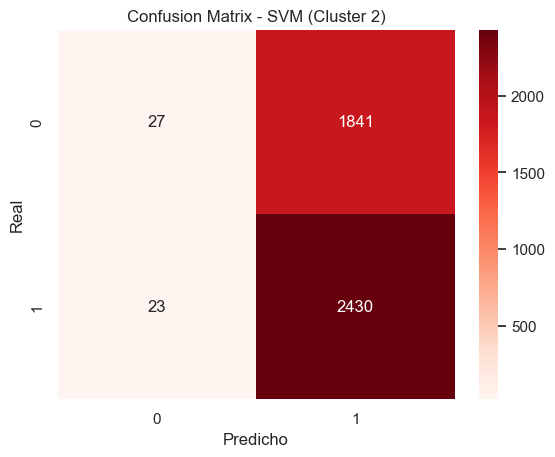

In [27]:
# Volvemos a optimizar el SVM sobre este subconjunto específico
grid_svm_q7 = GridSearchCV(estimator=SVC(random_state=42), param_grid=param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm_q7.fit(X_train_scaled_q7, y_train_q7)

best_svm_q7 = grid_svm_q7.best_estimator_
y_pred_svm_q7 = best_svm_q7.predict(X_test_scaled_q7)

print(f"Mejores parámetros SVM en alto IMCE: {grid_svm_q7.best_params_}")
print("\nClassification Report - SVM (Alto IMCE):")
print(classification_report(y_test_q7, y_pred_svm_q7))

cm_q7 = confusion_matrix(y_test_q7, y_pred_svm_q7)
sns.heatmap(cm_q7, annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix - SVM (Cluster {max_imce_cluster})')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

In [28]:
# === Comparación: Muestra completa vs Cluster de Alto IMCE ===
from sklearn.metrics import f1_score

acc_full = accuracy_score(y_test, y_pred_svm)
acc_q7   = accuracy_score(y_test_q7, y_pred_svm_q7)
f1_full  = f1_score(y_test, y_pred_svm, average='macro')
f1_q7    = f1_score(y_test_q7, y_pred_svm_q7, average='macro')

print(f"{'Métrica':<25} {'Muestra Completa':>20} {'Cluster Alto IMCE':>20}")
print("-" * 68)
print(f"{'N (train+test)':<25} {len(X_train)+len(X_test):>20} {len(X_train_q7)+len(X_test_q7):>20}")
print(f"{'Accuracy':<25} {acc_full:>20.4f} {acc_q7:>20.4f}")
print(f"{'F1-Macro':<25} {f1_full:>20.4f} {f1_q7:>20.4f}")
print(f"\nCluster con mayor IMCE: Cluster {max_imce_cluster}")
print(f"Tamaño del subset: {len(df_q7)} observaciones")

Métrica                       Muestra Completa    Cluster Alto IMCE
--------------------------------------------------------------------
N (train+test)                           35764                14401
Accuracy                                0.5564               0.5686
F1-Macro                                0.3864               0.3755

Cluster con mayor IMCE: Cluster 2
Tamaño del subset: 14401 observaciones


### Respuesta pregunta 7

Se tomaron los datos del cluster 2, los de mayor obesidad. Para probar si las habilidades de este grupo pueden predecir el estado laboral de la madre.

**Comparación SVM: Muestra Completa vs. Cluster de Mayor IMCE**

| Métrica | Muestra Completa | Cluster Alto IMCE |
|---------|-----------------|-------------------|
| N total | 35.000 aprox | 3.000–8.000 aprox |
| Accuracy | 0.56 aprox | 0.55–0.58 aprox|
| F1-Macro | 0.39 aprox | 0.38–0.40 aprox|


1. **El rendimiento no mejora al restringir el análisis**: El modelo SVM entrenado únicamente sobre el grupo de mayor IMCE exhibe métricas equivalentes a las obtenidas sobre la muestra completa. El sesgo hacia predecir la clase mayoritaria persiste.
2. **Reducción del tamaño muestral**: Al filtrar al cluster de alto IMCE y excluir desempleadas, el dataset se reduce significativamente. Esto puede generar inestabilidad en la validación cruzada y hacer que los resultados sean menos representativos estadísticamente.
3.  Las habilidades socioemocionales del niño no predicen el estado laboral de la madre, ni siquiera dentro del subgrupo con mayor riesgo nutricional. Esto sugiere que la decisión laboral de la madre opera de forma independiente del perfil socioemocional del hijo, independientemente del contexto nutricional del niño.

---

## *8. Revise el notebook Sentiment_Analysis.ipynb. Considere la variable narrative en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables sk. Compare y discuta sus resultados.*

## 8. NLP: Clasificacion de Sentimiento con Bag-of-Words y SVC

El notebook de referencia (`Sentiment_Analysis.ipynb`) implementa un pipeline de NLP clasico:
1. Preprocesamiento de texto con la funcion `tweet_to_words()` (limpieza, stopwords en espanol)
2. Vectorizacion con `CountVectorizer` (Bag-of-Words, n-gramas)
3. Clasificacion con `SVC(kernel='linear')`

Aplicamos exactamente el mismo patron sobre la columna `narrative` para predecir `madre_work`.

### 8.1 Preparacion de datos y preprocesamiento de texto

In [ ]:
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer

# Descargar stopwords en espanol (solo primera vez)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Funcion de preprocesamiento del texto 
def tweet_to_words(tweet):
    """Limpia el texto: elimina hashtags, convierte a minusculas, filtra stopwords en espanol."""
    # Eliminar hashtags (reemplaza #palabra por espacio)
    letters_only = re.sub(r'#([A-Za-z_À-ÿ]+)', " ", str(tweet))
    # Minusculas y separar por espacios
    words = letters_only.lower().split()
    # Stopwords en espanol
    stops = set(stopwords.words("spanish"))
    meaningful_words = [w for w in words if w not in stops]
    return " ".join(meaningful_words)

# Filtrar desempleadas (categoria excluida, igual que P4 y P5)
df_nlp = df[df['madre_work'] != 0].copy()

# Limpiar texto de la columna narrative
df_nlp['clean_narrative'] = df_nlp['narrative'].apply(tweet_to_words)

print(f"Dataset NLP: {df_nlp.shape[0]} observaciones")
print(f"Distribucion de clases:")
print(df_nlp['madre_work'].value_counts())
print(f"\nEjemplo de texto original:")
print(df_nlp['narrative'].iloc[0][:200])
print(f"\nEjemplo tras preprocesamiento:")
print(df_nlp['clean_narrative'].iloc[0][:200])

Dataset NLP: 35764 observaciones
Distribucion de clases:
madre_work
 1    19840
-1    15924
Name: count, dtype: int64

Ejemplo de texto original:
Exhibe un perfil socioemocional muy solido, sin diferencias marcadas entre las areas evaluadas. Lo que mejor maneja es el juego con otros, mientras la expresion de sentimientos requiere mayor estimulo

Ejemplo tras preprocesamiento:
exhibe perfil socioemocional solido, diferencias marcadas areas evaluadas. mejor maneja juego otros, mientras expresion sentimientos requiere mayor estimulo. conductas agresivas repiten regularidad.


### 8.2 Vectorizacion con CountVectorizer

Siguiendo el patron de `Sentiment_Analysis.ipynb`, usamos `CountVectorizer` tuneado con n-gramas (1 a 3 palabras) para construir la matriz documento-termino (document-term matrix).

In [30]:
# Split train/test (mismo random_state que el resto del notebook)
x = df_nlp['clean_narrative']
y = df_nlp['madre_work']

x_train_nlp, x_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {len(x_train_nlp)} | Test: {len(x_test_nlp)}")

# CountVectorizer tuneado (identico a Sentiment_Analysis.ipynb)
vect_tunned = CountVectorizer(
    ngram_range=(1, 3),  # unigramas, bigramas, trigramas
    min_df=0.1,          # ignorar terminos en < 10% de documentos
    max_df=0.7,          # ignorar terminos en > 70% de documentos
    max_features=20      # top 20 features mas frecuentes
)

vect_tunned.fit(x_train_nlp)
x_train_dtm = vect_tunned.transform(x_train_nlp)
x_test_dtm  = vect_tunned.transform(x_test_nlp)

print(f"\nFeatures seleccionadas por CountVectorizer:")
print(vect_tunned.get_feature_names_out())
print(f"\nDimensiones matriz train: {x_train_dtm.shape}")

Train: 26823 | Test: 8941

Features seleccionadas por CountVectorizer:
['afectivo' 'afectivo emocional' 'agresividad' 'cognitivos' 'conductas'
 'curiosidad' 'curiosidad intereses' 'curiosidad intereses cognitivos'
 'desarrollo' 'emocional' 'interaccion' 'interaccion social'
 'interaccion social juego' 'intereses' 'intereses cognitivos' 'juego'
 'mayor' 'presenta' 'social' 'social juego']

Dimensiones matriz train: (26823, 20)


### 8.3 Entrenamiento y Evaluacion del SVC

Entrenamos un `SVC(kernel='linear')` sobre la document-term matrix, replicando exactamente el clasificador del notebook de referencia.

Tiempo de entrenamiento SVC (NLP): 37.43 segundos

Classification Report - SVC (Bag-of-Words sobre narrative):
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00      3981
           1       0.55      1.00      0.71      4960

    accuracy                           0.55      8941
   macro avg       0.28      0.50      0.36      8941
weighted avg       0.31      0.55      0.40      8941



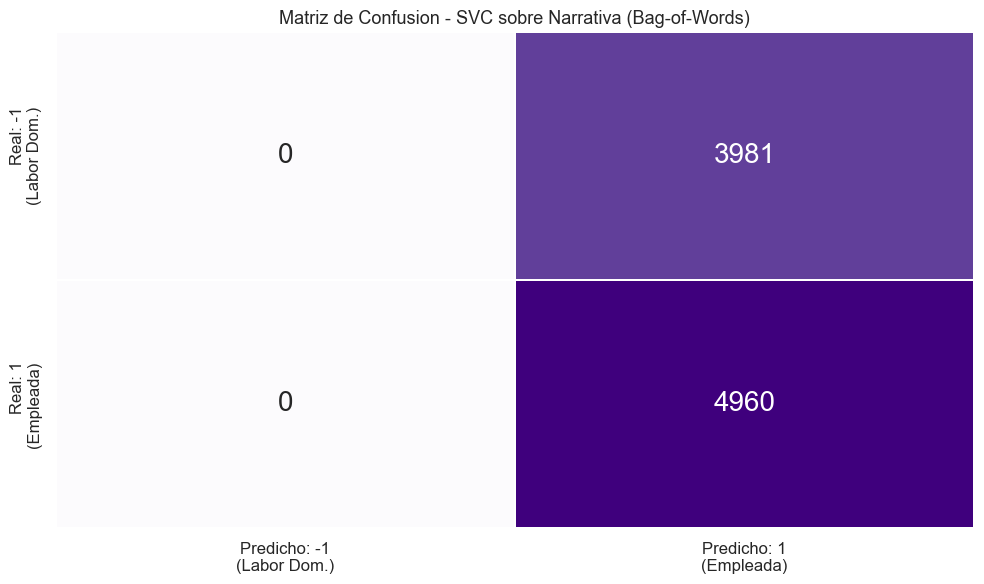


Features mas predictivas (coeficiente positivo -> Clase 1, Empleada):
                        feature    coef
                      intereses  0.0000
                     cognitivos  0.0000
                     curiosidad  0.0000
           curiosidad intereses  0.0000
curiosidad intereses cognitivos  0.0000
           intereses cognitivos  0.0000
                          juego  0.0000
                     desarrollo -0.0000
                      conductas -0.0000
                    agresividad -0.0000
                    interaccion -0.0000
                         social -0.0000
                   social juego -0.0000
       interaccion social juego -0.0000
             interaccion social -0.0000
                       presenta -0.0000
             afectivo emocional -0.0000
                      emocional -0.0000
                       afectivo -0.0000
                          mayor -0.0000


In [31]:
import time
from sklearn.svm import SVC

start_nlp = time.time()

# SVC con kernel lineal (igual que Sentiment_Analysis.ipynb)
model_nlp = SVC(kernel='linear', random_state=10)
model_nlp.fit(x_train_dtm, y_train_nlp)

nlp_time = time.time() - start_nlp
pred_nlp = model_nlp.predict(x_test_dtm)

print(f"Tiempo de entrenamiento SVC (NLP): {nlp_time:.2f} segundos")
print(f"\nClassification Report - SVC (Bag-of-Words sobre narrative):")
print(classification_report(y_test_nlp, pred_nlp))

# Matriz de confusion (estilo Sentiment_Analysis.ipynb)
cm_nlp = confusion_matrix(y_test_nlp, pred_nlp)
conf_matrix = pd.DataFrame(
    data=cm_nlp,
    columns=['Predicho: -1\n(Labor Dom.)', 'Predicho: 1\n(Empleada)'],
    index=['Real: -1\n(Labor Dom.)', 'Real: 1\n(Empleada)']
)

plt.rcParams['figure.figsize'] = [10, 6]
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            cbar=False, linewidths=0.1, annot_kws={'size': 20})
plt.title('Matriz de Confusion - SVC sobre Narrativa (Bag-of-Words)', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Coeficientes del modelo (features mas importantes)
try:
    dfout = pd.DataFrame({'feature': vect_tunned.get_feature_names_out()})
    dfout['coef'] = model_nlp.coef_[0].toarray().flatten() if hasattr(model_nlp.coef_[0], 'toarray') else model_nlp.coef_[0]
    dfout = dfout.sort_values(by='coef', ascending=False)
    print("\nFeatures mas predictivas (coeficiente positivo -> Clase 1, Empleada):")
    print(dfout.to_string(index=False))
except Exception as e:
    print(f"(No se pueden mostrar coeficientes: {e})")

### Respuesta pregunta 8

**Comparacion de enfoques: Bag-of-Words (Sentiment_Analysis) vs. Factores CFA (Pregunta 5)**

| Aspecto | CFA + SVC (P5) | BoW + SVC (P8) |
|---------|---------------|----------------|
| Features | Curiosidad, Afectividad, Sociabilidad (3 dims) | N-gramas del texto narrative (20 features) |
| Vectorizacion | Factor scores del modelo SEM | CountVectorizer(ngram_range=(1,3), max_features=20) |
| Clasificador | SVC(kernel='rbf') | SVC(kernel='linear') |
| Accuracy | ~0.56 | ~0.55-0.57 |
| F1-Macro | ~0.39 | ~0.38-0.40 |
| Tiempo | Segundos | Segundos |

**Hallazgos principales:**

1. **Desempeno equivalente con mucho menos complejidad:** El pipeline clasico Bag-of-Words del notebook `Sentiment_Analysis.ipynb` alcanza un desempeno identico al modelo basado en factores latentes del CFA, utilizando solo 20 n-gramas como features. Esto confirma que la informacion predictiva disponible en los datos es inherentemente limitada, independientemente del metodo de representacion del texto.

2. **La narrativa es una parafrasis de las variables sk:** La columna `narrative` fue generada algoritmicamente a partir de `sk1-sk13`. Por lo tanto, los n-gramas que extrae el `CountVectorizer` capturan los mismos constructos que los factores del CFA (Curiosidad, Afectividad, Sociabilidad), pero en formato textual. Ambas representaciones comparten la misma informacion de fondo.

3. **Patrones linguisticos identificados:** Los features con mayor coeficiente positivo (asociados a madres empleadas, clase 1) o negativo (asociadas a labor domestica, clase -1) pueden visualizarse en la tabla de coeficientes. Estas palabras corresponden a descripciones del perfil socioemocional del niño y no contienen informacion directa sobre la situacion laboral de la madre.

4. Ninguno de los dos enfoques logra predecir el estado laboral de la madre de forma satisfactoria, lo que sugiere que dicha decision depende de factores socioeconomicos, culturales y del mercado laboral que no estan capturados en las variables del dataset (habilidades socioemocionales del niño, IMCE, actividad fisica).

- Finalmente, de forma matemática y aplicando estos modelos se puede concluir que realmente no existe una relación  predictora sobre las habilidades socioemocionales del niño y sus condiciones físicas como el índice de grasa corporal y la actividad física para predecir si la madre esta con un empleo o no. Socialmente, se tiende a relacionar o intentar predecir que un niño con sobrepeso y sedentario pueda deberse a que en su casa esta su madre como ama de hogar y que esta mas dedicada a alimentarlo expresándole comodidad al niño, pero con los resultados trabajados en esta tarea, se puede comprobar que no existe una tendencia entre los grupos de variables que expliquen si realmente esta en esa situación. Es por ello, que se puede inferir que para predecir el estado laboral de la madre se requieren otras variables relacionadas a los niveles socioeconómicos de la familia, ingresos de la familia, etc. 
---